# Module

## Meta
- learn
    - https://colah.github.io/posts/2015-08-Understanding-LSTMs/
    - https://distill.pub/2019/memorization-in-rnns/
- code
    - https://github.com/georgeyiasemis/Recurrent-Neural-Networks-from-scratch-using-PyTorch/
- changes
    - convert to pytorch 2 API (the `Variable` class has been deprecated)
    - refined by me (hamidb80) and help of DeepSeek
- log
    - 2021 original code (georgeyiasemis)
    - 2026 hamidb80 changes 

## Imports

In [103]:
import numpy  as np
import pandas as pd

import torch
import torch.nn  as nn

## Utils

In [104]:
def reset_parameters(model):
    std = 1.0 / np.sqrt(model.hidden_size)
    for w in model.parameters():
        w.data.uniform_(-std, std)

--------

# RNN

## Cell

### impl

In [105]:
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True, nonlinearity=torch.tanh):
        super().__init__()

        self.input_size   = input_size
        self.hidden_size  = hidden_size
        self.bias         = bias
        self.nonlinearity = nonlinearity

        self.x2h = nn.Linear(input_size,  hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, hidden_size, bias=bias)

    def forward(self, input, hx=None):
        # Inputs:
        #   input: (batch_size, input_size)
        #   hx:    (batch_size, hidden_size)
        # Output:
        #   hy:    (batch_size, hidden_size)
        
        batch_size = input.size(0)
        hx = torch.zeros(batch_size, self.hidden_size, device=input.device, dtype=input.dtype) if hx is None else hx
        hy = self.nonlinearity(self.x2h(input) + self.h2h(hx))
        return hy

### test

In [106]:
cell = RNNCell(input_size=10, hidden_size=20)

h = None  # Will be initialized on first call
for t in range(3):
    x_t = torch.randn(4, 10)
    h = cell(x_t, h)  # Pass previous hidden state
    print(f"Step {t+1}: h shape {h.shape}")

Step 1: h shape torch.Size([4, 20])
Step 2: h shape torch.Size([4, 20])
Step 3: h shape torch.Size([4, 20])


## Module

### pytorch

In [107]:
class PyTorchRNNModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hx=None):
        output, h_n = self.rnn(input, hx)
        out = self.fc(output[:, -1, :])  # Take last timestep
        return out, h_n

### impl

In [108]:
class CustomRNNModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, bias, activation=torch.tanh):
        super().__init__()
        
        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.bias        = bias
        self.output_size = output_size
        self.rnn_cell_list = nn.ModuleList([
              RNNCell(input_size,  hidden_size, bias, activation),
            *[RNNCell(hidden_size, hidden_size, bias, activation) for _ in range(1, num_layers)],
        ])
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hx=None):
        outputs = []
        batch_size, seq_len, _ = input.size() # input: (batch_size, seq_len, input_size)

        hx = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=input.device, dtype=input.dtype) if hx is None else hx # Initialize hidden states
        hidden  = [hx[layer] for layer in range(self.num_layers)] # hx: (num_layers, batch_size, hidden_size) -> list of (batch_size, hidden_size)
        
        for t in range(seq_len):
            for layer in range(self.num_layers):
                x_t = input[:, t, :] if layer == 0 else hidden[layer - 1]  # (batch_size, input_size)
                hidden[layer] = self.rnn_cell_list[layer](x_t, hidden[layer])
            outputs.append(hidden[-1])
        
        out = self.fc(outputs[-1]) # (batch_size, hidden_size)
        return out, torch.stack(hidden) 

### test

In [109]:
model = CustomRNNModule(
    input_size=10,
    hidden_size=20,
    num_layers=2,
    output_size=1,
    bias=True,
    activation=torch.tanh
)

h = None

# Process sequence step by step
for t in range(5):
    x_t = torch.randn(4, 10)  # (batch_size, input_size)
    out, h = model(x_t.unsqueeze(1), h)  # unsqueeze to add seq_len dimension
    print(f"Step {t+1}: output shape {out.shape}, hidden shape {h.shape}")

Step 1: output shape torch.Size([4, 1]), hidden shape torch.Size([2, 4, 20])
Step 2: output shape torch.Size([4, 1]), hidden shape torch.Size([2, 4, 20])
Step 3: output shape torch.Size([4, 1]), hidden shape torch.Size([2, 4, 20])
Step 4: output shape torch.Size([4, 1]), hidden shape torch.Size([2, 4, 20])
Step 5: output shape torch.Size([4, 1]), hidden shape torch.Size([2, 4, 20])


# LSTM

## Cell

### impl

In [110]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super().__init__()

        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.bias        = bias

        self.xh = nn.Linear(input_size,  hidden_size * 4, bias=bias)
        self.hh = nn.Linear(hidden_size, hidden_size * 4, bias=bias)

    def forward(self, input, hx=None):
        # Inputs:
        #       input:  (batch_size, input_size)
        #       hx:     (batch_size, hidden_size)
        # Outputs:
        #       hy:     (batch_size, hidden_size)
        #       cy:     (batch_size, hidden_size)

        if hx is None:
            hx = torch.zeros(input.size(0), self.hidden_size, device=input.device, dtype=input.dtype)
            cx = torch.zeros(input.size(0), self.hidden_size, device=input.device, dtype=input.dtype)
            hx = (hx, cx)

        hx, cx = hx
        gates = self.xh(input) + self.hh(hx)

        # Get gates (i_t, f_t, g_t, o_t)
        input_gate, forget_gate, cell_gate, output_gate = gates.chunk(4, 1)
        # it's equivalent to
        # i_t = gates[:, 0            :1*hidden_size]
        # f_t = gates[:, 1*hidden_size:2*hidden_size]
        # g_t = gates[:, 2*hidden_size:3*hidden_size]
        # o_t = gates[:, 3*hidden_size:4*hidden_size]

        i_t = torch.sigmoid(input_gate)
        f_t = torch.sigmoid(forget_gate)
        g_t = torch.   tanh(cell_gate)
        o_t = torch.sigmoid(output_gate)

        cy = cx * f_t + i_t * g_t
        hy = o_t * torch.tanh(cy)
        return (hy, cy)

### test

In [111]:
cell = LSTMCell(input_size=10, hidden_size=20)

# Initialize hidden states
h = None
c = None

for t in range(3):
    x_t = torch.randn(4, 10)
    if h is None:
        h, c = cell(x_t)  # First call auto-initializes
    else:
        h, c = cell(x_t, (h, c))  # Subsequent calls pass both
    
    print(f"Step {t+1}: h shape {h.shape}, c shape {c.shape}")

Step 1: h shape torch.Size([4, 20]), c shape torch.Size([4, 20])
Step 2: h shape torch.Size([4, 20]), c shape torch.Size([4, 20])
Step 3: h shape torch.Size([4, 20]), c shape torch.Size([4, 20])


## Module

### Pytorch

In [112]:
class PyTorchLSTMModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hx=None):
        output, (h_n, c_n) = self.lstm(input, hx)
        out = self.fc(output[:, -1, :])
        return out, (h_n, c_n)

### impl

In [113]:
class CustomLSTMModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, bias):
        super().__init__()

        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.bias        = bias
        self.output_size = output_size
        self.rnn_cell_list = nn.ModuleList([
              LSTMCell(self.input_size,  self.hidden_size, self.bias),
            *[LSTMCell(self.hidden_size, self.hidden_size, self.bias) for _ in range(1, self.num_layers)]
        ])
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hx=None):
        # Input:  (batch_size, seq_len, input_size)
        # Output: (batch_size, output_size)
        # hx:     tuple of (h0, c0) each (num_layers, batch_size, hidden_size)
        
        batch_size, seq_len, _ = input.size()
        
        # Initialize hidden states if not provided
        if hx is None:
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=input.device, dtype=input.dtype)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=input.device, dtype=input.dtype)
        else:
            h0, c0 = hx
        
        # Initialize per-layer hidden states
        hidden = [(h0[layer], c0[layer]) for layer in range(self.num_layers)] # Each: (h, c) of shape (batch_size, hidden_size)
        
        # Process sequence
        outputs = []
        for t in range(seq_len):
            for layer in range(self.num_layers):
                # First layer takes input, others take previous layer's hidden state
                x_t = input[:, t, :] if layer == 0 else hidden[layer - 1][0]
                
                # Update hidden state for this layer
                h_prev, c_prev = hidden[layer]
                h_new,   c_new = self.rnn_cell_list[layer](x_t, (h_prev, c_prev))
                hidden[layer]  = (h_new, c_new)
            
            # Collect top layer's hidden state as output
            outputs.append(hidden[-1][0])
        
        out = self.fc(outputs[-1])  # Shape: (batch_size, output_size)
        
        # Return output and final hidden states (matching PyTorch API)
        h_n = torch.stack([h for h, c in hidden])  # (num_layers, batch_size, hidden_size)
        c_n = torch.stack([c for h, c in hidden])  # (num_layers, batch_size, hidden_size)
        
        return out, (h_n, c_n)

### test

In [114]:
# Create model
model = CustomLSTMModule(
    input_size=10,
    hidden_size=20,
    num_layers=2,
    output_size=1,
    bias=True,
)

# Test single forward
x = torch.randn(4, 3, 10)  # (batch_size, seq_len, input_size)
out, (h_n, c_n) = model(x)

print(f"Output shape: {out.shape}")      # (4, 1)
print(f"h_n shape: {h_n.shape}")         # (2, 4, 20)
print(f"c_n shape: {c_n.shape}")         # (2, 4, 20)

# Test multi-step with manual hidden state
h = None
for t in range(3):
    x_t = torch.randn(4, 10)
    out, (h, c) = model(x_t.unsqueeze(1), (h, c) if h is not None else None)
    print(f"Step {t+1}: output {out.shape}")

Output shape: torch.Size([4, 1])
h_n shape: torch.Size([2, 4, 20])
c_n shape: torch.Size([2, 4, 20])
Step 1: output torch.Size([4, 1])
Step 2: output torch.Size([4, 1])
Step 3: output torch.Size([4, 1])


# GRU

## Cell

### impl

In [115]:
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super().__init__()
        
        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.bias        = bias
        
        # Combined linear layers for efficiency
        self.x2h = nn.Linear(input_size, 3 * hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, 3 * hidden_size, bias=bias)

    def forward(self, input, hx=None):
        # Inputs:
        #   input: (batch_size, input_size)
        #   hx:    (batch_size, hidden_size)
        # Output:
        #   hy:    (batch_size, hidden_size)
        
        batch_size = input.size(0)
        hx = torch.zeros(batch_size, self.hidden_size, device=input.device, dtype=input.dtype) if hx is None else hx
        
        # Project input and hidden state
        x_t = self.x2h(input)  # (batch_size, 3 * hidden_size)
        h_t = self.h2h(hx)     # (batch_size, 3 * hidden_size)
        
        # Split into reset, update, and candidate gates
        x_reset, x_update, x_candidate = x_t.chunk(3, 1)
        h_reset, h_update, h_candidate = h_t.chunk(3, 1)
        
        # Apply activations
        reset_gate     = torch.sigmoid(x_reset + h_reset)   # r_t
        update_gate    = torch.sigmoid(x_update + h_update) # z_t
        candidate_gate = torch.tanh(x_candidate + reset_gate * h_candidate)  # n_t
        
        # Update hidden state
        hy = update_gate * hx + (1 - update_gate) * candidate_gate
        
        return hy

### test

In [116]:
cell = GRUCell(input_size=10, hidden_size=20)

h = None  # Will be initialized on first call
for t in range(3):
    x_t = torch.randn(4, 10)
    h = cell(x_t, h)  # Pass previous hidden state
    print(f"Step {t+1}: h shape {h.shape}")

Step 1: h shape torch.Size([4, 20])
Step 2: h shape torch.Size([4, 20])
Step 3: h shape torch.Size([4, 20])


## Module

### Pytorch

In [117]:
class PyTorchGRUModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hx=None):
        output, h_n = self.gru(input, hx)
        out = self.fc(output[:, -1, :])
        return out, h_n

### impl

In [118]:
class CustomGRUModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, bias):
        super().__init__()

        self.input_size    = input_size
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bias          = bias
        self.output_size   = output_size
        self.rnn_cell_list = nn.ModuleList([
              GRUCell(self.input_size,  self.hidden_size, self.bias),
            *[GRUCell(self.hidden_size, self.hidden_size, self.bias) for _ in range(1, self.num_layers)]
        ])
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hx=None):
        # Input:  (batch_size, seq_len, input_size)
        # Output: (batch_size, output_size)
        # hx:     (num_layers, batch_size, hidden_size)
        
        batch_size, seq_len, _ = input.size()
        hx = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=input.device, dtype=input.dtype) if hx is None else hx

        hidden  = [hx[layer] for layer in range(self.num_layers)]
        outputs = []

        for t in range(seq_len):
            for layer in range(self.num_layers):
                x_t =  input[:, t, :] if layer == 0 else hidden[layer - 1]  # Previous layer's hidden state
                hidden[layer] = self.rnn_cell_list[layer](x_t, hidden[layer])
            outputs.append(hidden[-1])
        
        out = self.fc(outputs[-1])  # Shape: (batch_size, output_size)
        h_n = torch.stack(hidden)   # (num_layers, batch_size, hidden_size)
        return out, h_n

### test

In [ ]:
# Create model
model = CustomGRUModule(
    input_size=10,
    hidden_size=20,
    num_layers=2,
    output_size=1,
    bias=True,
)

# Test single forward
x = torch.randn(4, 3, 10)  # (batch_size, seq_len, input_size)
out, h_n = model(x)

print(f"Output shape: {out.shape}")  # (4, 1)
print(f"h_n shape: {h_n.shape}")     # (2, 4, 20)

# Test multi-step with manual hidden state
h = None
for t in range(3):
    x_t = torch.randn(4, 10)
    out, h = model(x_t.unsqueeze(1), h)
    print(f"Step {t+1}: output {out.shape}, hidden {h.shape}")

Output shape: torch.Size([4, 1])
h_n shape: torch.Size([2, 4, 20])
Step 1: output torch.Size([4, 1]), hidden torch.Size([2, 4, 20])
Step 2: output torch.Size([4, 1]), hidden torch.Size([2, 4, 20])
Step 3: output torch.Size([4, 1]), hidden torch.Size([2, 4, 20])


-----

# Usage

## Imports

In [ ]:
import time

import numpy as np

import torch
import torch.nn         as nn
import torch.optim      as optim
from   torch.utils.data import DataLoader, TensorDataset

from   sklearn.datasets      import make_regression
from   sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## Config

### Hyperparameters

In [121]:
BATCH_SIZE   = 64
INPUT_SIZE   =  8
HIDDEN_SIZE  = 32
NUM_LAYERS   =  2
OUTPUT_SIZE  =  1
EPOCHS       =  7
LR           =  0.001

### setup

In [122]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


## Functionalities

### Dataset

In [123]:
def generate_sequence_dataset(n_samples=5000, seq_len=10, input_size=8, output_size=1, noise=0.1):
    """Generate a simple autoregressive dataset."""
    X = []
    y = []
    
    for _ in range(n_samples):
        # Generate random sequence
        seq = torch.randn(seq_len, input_size)
        
        # Target: sum of last 3 timesteps + noise
        target = seq[-3:].sum(dim=0).mean().item() + noise * torch.randn(1).item()
        
        X.append(seq)
        y.append(target)
    
    X = torch.stack(X)  # (n_samples, seq_len, input_size)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (n_samples, 1)
    
    return X, y

### Training

In [124]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE):
    """Train a model and return loss history."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    epoch_times = []
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Training
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            output, _ = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item() * batch_X.size(0)
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                output, _ = model(batch_X)
                loss = criterion(output, batch_y)
                epoch_val_loss += loss.item() * batch_X.size(0)
        
        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        epoch_times.append(time.time() - start_time)
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.6f}, Val Loss: {epoch_val_loss:.6f}, Time: {epoch_times[-1]:.2f}s")
    
    return train_losses, val_losses, epoch_times

## Compare with Pytorch's models

### generate data

In [125]:
X, y = generate_sequence_dataset(n_samples=5000, seq_len=10, input_size=8)

train_size     = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(X_train)}, Val samples:  {len(X_val) }")
print(f"Input shape:   {    X.shape},  Target shape: {    y.shape}")

Train samples: 4000, Val samples:  1000
Input shape:   torch.Size([5000, 10, 8]),  Target shape: torch.Size([5000, 1])


### RNN

#### train

In [ ]:
custom_rnn  =  CustomRNNModule(INPUT_SIZE, HIDDEN_SIZE ,NUM_LAYERS, OUTPUT_SIZE, bias=True)
pytorch_rnn = PyTorchRNNModule(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

custom_train_loss,   custom_val_loss,  custom_times = train_model( custom_rnn, train_loader, val_loader, epochs=EPOCHS, lr=LR)
pytorch_train_loss, pytorch_val_loss, pytorch_times = train_model(pytorch_rnn, train_loader, val_loader, epochs=EPOCHS, lr=LR)

custom_total_time  = sum( custom_times)
pytorch_total_time = sum(pytorch_times)

Epoch 1/7 - Train Loss: 0.176526, Val Loss: 0.037072, Time: 0.55s
Epoch 2/7 - Train Loss: 0.025295, Val Loss: 0.025397, Time: 0.58s
Epoch 3/7 - Train Loss: 0.021243, Val Loss: 0.023512, Time: 0.44s
Epoch 4/7 - Train Loss: 0.020026, Val Loss: 0.021718, Time: 0.58s
Epoch 5/7 - Train Loss: 0.018689, Val Loss: 0.021112, Time: 0.47s
Epoch 6/7 - Train Loss: 0.018077, Val Loss: 0.019726, Time: 0.41s
Epoch 7/7 - Train Loss: 0.016986, Val Loss: 0.019381, Time: 0.41s
Epoch 1/7 - Train Loss: 0.119969, Val Loss: 0.020849, Time: 0.31s
Epoch 2/7 - Train Loss: 0.016443, Val Loss: 0.017120, Time: 0.29s
Epoch 3/7 - Train Loss: 0.014982, Val Loss: 0.016324, Time: 0.48s
Epoch 4/7 - Train Loss: 0.014565, Val Loss: 0.014782, Time: 0.38s
Epoch 5/7 - Train Loss: 0.013814, Val Loss: 0.014492, Time: 0.36s
Epoch 6/7 - Train Loss: 0.013702, Val Loss: 0.014416, Time: 0.32s
Epoch 7/7 - Train Loss: 0.013215, Val Loss: 0.014361, Time: 0.35s


#### plot

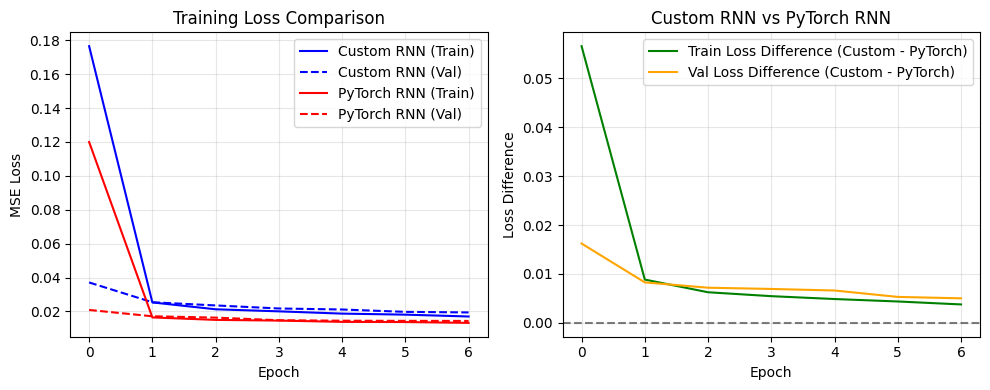

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loss comparison
axes[0].plot(custom_train_loss,  label='Custom RNN (Train)',  color='blue', linestyle='-')
axes[0].plot(  custom_val_loss,  label='Custom RNN (Val)',    color='blue', linestyle='--')
axes[0].plot(pytorch_train_loss, label='PyTorch RNN (Train)', color='red',  linestyle='-')
axes[0].plot(  pytorch_val_loss, label='PyTorch RNN (Val)',   color='red',  linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss difference
diff_train = np.array(custom_train_loss) - np.array(pytorch_train_loss)
diff_val   = np.array(custom_val_loss)   - np.array(pytorch_val_loss)
axes[1].plot(diff_train, label='Train Loss Difference (Custom - PyTorch)', color='green')
axes[1].plot(diff_val,   label='Val Loss Difference (Custom - PyTorch)',   color='orange')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss Difference')
axes[1].set_title('Custom RNN vs PyTorch RNN')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### report

In [128]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Custom RNN  - Final Train Loss: {custom_train_loss[-1]:.6f}, Val Loss: {custom_val_loss[-1]:.6f}, Total Time: {custom_total_time:.2f}s")
print(f"PyTorch RNN - Final Train Loss: {pytorch_train_loss[-1]:.6f}, Val Loss: {pytorch_val_loss[-1]:.6f}, Total Time: {pytorch_total_time:.2f}s")
print(f"Final Loss Difference (Train): {custom_train_loss[-1] - pytorch_train_loss[-1]:.6f}")
print(f"Final Loss Difference (Val):   {custom_val_loss[-1] - pytorch_val_loss[-1]:.6f}")
print(f"Speed Difference: {custom_total_time / pytorch_total_time:.2f}x slower")


SUMMARY
Custom RNN  - Final Train Loss: 0.016986, Val Loss: 0.019381, Total Time: 3.45s
PyTorch RNN - Final Train Loss: 0.013215, Val Loss: 0.014361, Total Time: 2.50s
Final Loss Difference (Train): 0.003771
Final Loss Difference (Val):   0.005020
Speed Difference: 1.38x slower


### LSTM

#### train

In [ ]:
custom_model  =  CustomLSTMModule(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, bias=True)
pytorch_model = PyTorchLSTMModule(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

custom_train_loss,   custom_val_loss,  custom_times = train_model( custom_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)
pytorch_train_loss, pytorch_val_loss, pytorch_times = train_model(pytorch_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)

custom_total_time  = sum(custom_times)
pytorch_total_time = sum(pytorch_times)

Epoch 1/7 - Train Loss: 0.272336, Val Loss: 0.096519, Time: 1.72s
Epoch 2/7 - Train Loss: 0.050308, Val Loss: 0.045079, Time: 1.37s
Epoch 3/7 - Train Loss: 0.040363, Val Loss: 0.040322, Time: 0.90s
Epoch 4/7 - Train Loss: 0.036018, Val Loss: 0.039296, Time: 1.41s
Epoch 5/7 - Train Loss: 0.034046, Val Loss: 0.036112, Time: 0.79s
Epoch 6/7 - Train Loss: 0.032698, Val Loss: 0.037246, Time: 0.91s
Epoch 7/7 - Train Loss: 0.030964, Val Loss: 0.034245, Time: 2.22s
Epoch 1/7 - Train Loss: 0.299500, Val Loss: 0.137201, Time: 0.57s
Epoch 2/7 - Train Loss: 0.056526, Val Loss: 0.045202, Time: 0.31s
Epoch 3/7 - Train Loss: 0.037947, Val Loss: 0.039828, Time: 0.28s
Epoch 4/7 - Train Loss: 0.035002, Val Loss: 0.036876, Time: 0.30s
Epoch 5/7 - Train Loss: 0.033140, Val Loss: 0.036175, Time: 1.12s
Epoch 6/7 - Train Loss: 0.031983, Val Loss: 0.034229, Time: 0.26s
Epoch 7/7 - Train Loss: 0.030442, Val Loss: 0.033428, Time: 0.25s


#### plot

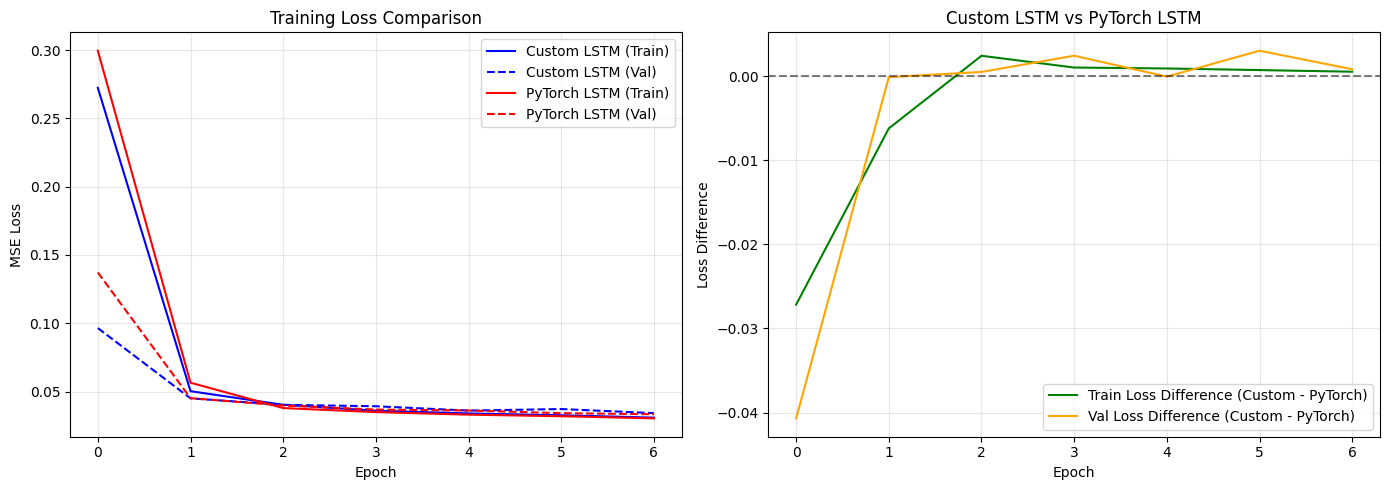

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(custom_train_loss, label='Custom LSTM (Train)', color='blue', linestyle='-')
axes[0].plot(custom_val_loss, label='Custom LSTM (Val)', color='blue', linestyle='--')
axes[0].plot(pytorch_train_loss, label='PyTorch LSTM (Train)', color='red', linestyle='-')
axes[0].plot(pytorch_val_loss, label='PyTorch LSTM (Val)', color='red', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss difference
diff_train = np.array(custom_train_loss) - np.array(pytorch_train_loss)
diff_val = np.array(custom_val_loss) - np.array(pytorch_val_loss)
axes[1].plot(diff_train, label='Train Loss Difference (Custom - PyTorch)', color='green')
axes[1].plot(diff_val, label='Val Loss Difference (Custom - PyTorch)', color='orange')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss Difference')
axes[1].set_title('Custom LSTM vs PyTorch LSTM')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### report

In [131]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Custom LSTM  - Final Train Loss: {custom_train_loss[-1]:.6f}, Val Loss: {custom_val_loss[-1]:.6f}, Total Time: {custom_total_time:.2f}s")
print(f"PyTorch LSTM - Final Train Loss: {pytorch_train_loss[-1]:.6f}, Val Loss: {pytorch_val_loss[-1]:.6f}, Total Time: {pytorch_total_time:.2f}s")
print(f"Final Loss Difference (Train): {custom_train_loss[-1] - pytorch_train_loss[-1]:.6f}")
print(f"Final Loss Difference (Val):   {custom_val_loss[-1] - pytorch_val_loss[-1]:.6f}")
print(f"Speed Difference: {custom_total_time / pytorch_total_time:.2f}x slower")


SUMMARY
Custom LSTM  - Final Train Loss: 0.030964, Val Loss: 0.034245, Total Time: 9.33s
PyTorch LSTM - Final Train Loss: 0.030442, Val Loss: 0.033428, Total Time: 3.08s
Final Loss Difference (Train): 0.000522
Final Loss Difference (Val):   0.000817
Speed Difference: 3.03x slower


### GRU

#### train

In [132]:
custom_model  =  CustomGRUModule(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, bias=True)
pytorch_model = PyTorchGRUModule(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

custom_train_loss,   custom_val_loss,  custom_times = train_model( custom_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)
pytorch_train_loss, pytorch_val_loss, pytorch_times = train_model(pytorch_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)

custom_total_time  = sum(custom_times)
pytorch_total_time = sum(pytorch_times)

Epoch 1/7 - Train Loss: 0.221348, Val Loss: 0.070515, Time: 3.28s
Epoch 2/7 - Train Loss: 0.049961, Val Loss: 0.047949, Time: 1.19s
Epoch 3/7 - Train Loss: 0.039790, Val Loss: 0.042283, Time: 1.17s
Epoch 4/7 - Train Loss: 0.036857, Val Loss: 0.040880, Time: 1.92s
Epoch 5/7 - Train Loss: 0.035430, Val Loss: 0.040292, Time: 1.79s
Epoch 6/7 - Train Loss: 0.034594, Val Loss: 0.039163, Time: 1.10s
Epoch 7/7 - Train Loss: 0.032983, Val Loss: 0.036614, Time: 0.95s
Epoch 1/7 - Train Loss: 0.195151, Val Loss: 0.051712, Time: 0.64s
Epoch 2/7 - Train Loss: 0.040229, Val Loss: 0.040396, Time: 0.75s
Epoch 3/7 - Train Loss: 0.034917, Val Loss: 0.035409, Time: 1.91s
Epoch 4/7 - Train Loss: 0.032784, Val Loss: 0.034383, Time: 0.73s
Epoch 5/7 - Train Loss: 0.031232, Val Loss: 0.034734, Time: 0.70s
Epoch 6/7 - Train Loss: 0.030421, Val Loss: 0.033088, Time: 0.99s
Epoch 7/7 - Train Loss: 0.027318, Val Loss: 0.026662, Time: 0.80s


#### plot

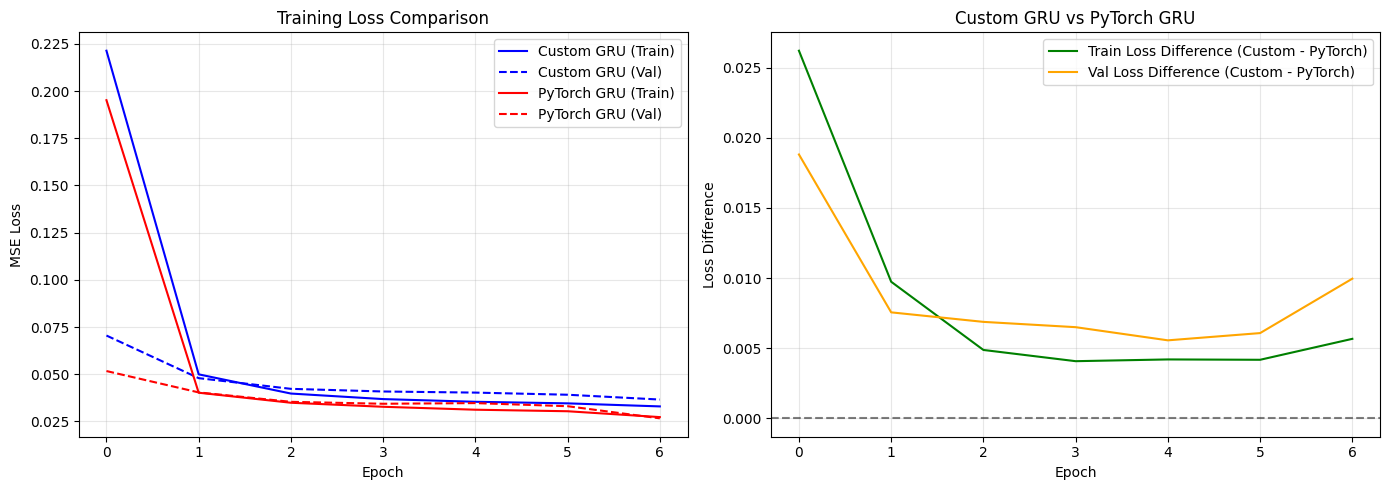

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(custom_train_loss, label='Custom GRU (Train)', color='blue', linestyle='-')
axes[0].plot(custom_val_loss, label='Custom GRU (Val)', color='blue', linestyle='--')
axes[0].plot(pytorch_train_loss, label='PyTorch GRU (Train)', color='red', linestyle='-')
axes[0].plot(pytorch_val_loss, label='PyTorch GRU (Val)', color='red', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss difference
diff_train = np.array(custom_train_loss) - np.array(pytorch_train_loss)
diff_val = np.array(custom_val_loss) - np.array(pytorch_val_loss)
axes[1].plot(diff_train, label='Train Loss Difference (Custom - PyTorch)', color='green')
axes[1].plot(diff_val, label='Val Loss Difference (Custom - PyTorch)', color='orange')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss Difference')
axes[1].set_title('Custom GRU vs PyTorch GRU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### report

In [134]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Custom GRU  - Final Train Loss: {custom_train_loss[-1]:.6f}, Val Loss: {custom_val_loss[-1]:.6f}, Total Time: {custom_total_time:.2f}s")
print(f"PyTorch GRU - Final Train Loss: {pytorch_train_loss[-1]:.6f}, Val Loss: {pytorch_val_loss[-1]:.6f}, Total Time: {pytorch_total_time:.2f}s")
print(f"Final Loss Difference (Train): {custom_train_loss[-1] - pytorch_train_loss[-1]:.6f}")
print(f"Final Loss Difference (Val):   {custom_val_loss[-1] - pytorch_val_loss[-1]:.6f}")
print(f"Speed Difference: {custom_total_time / pytorch_total_time:.2f}x slower")


SUMMARY
Custom GRU  - Final Train Loss: 0.032983, Val Loss: 0.036614, Total Time: 11.39s
PyTorch GRU - Final Train Loss: 0.027318, Val Loss: 0.026662, Total Time: 6.53s
Final Loss Difference (Train): 0.005665
Final Loss Difference (Val):   0.009952
Speed Difference: 1.74x slower
